In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
np.random.seed(42)
N = 2000  # 2000 women

def generate_mouna_dataset(n=2000):
    data = []
    for i in range(n):
        # ── demographic ──────────────────────────────────────
        age = np.random.normal(52, 12)
        age = np.clip(age, 30, 75)

        bmi = np.random.normal(27, 5)
        bmi = np.clip(bmi, 16, 50)

        # ── reproductive history ─────────────────────────────
        age_menarche   = np.random.choice([11, 12, 13, 14, 15],
                          p=[0.10, 0.25, 0.35, 0.20, 0.10])
        age_menopause  = np.random.normal(50, 4)
        age_menopause  = np.clip(age_menopause, 40, 60)
        parity         = np.random.choice([0, 1, 2, 3, 4],
                          p=[0.15, 0.20, 0.35, 0.20, 0.10])
        breastfeeding  = np.random.choice([0, 1], p=[0.35, 0.65])
        breastfeed_yrs = np.random.exponential(1.5) if breastfeeding else 0

        # ── family history ───────────────────────────────────
        fam_hist_1st   = np.random.choice([0, 1], p=[0.85, 0.15])
        fam_hist_2nd   = np.random.choice([0, 1], p=[0.75, 0.25])
        brca_mutation  = np.random.choice([0, 1], p=[0.98, 0.02])

        # ── lifestyle ────────────────────────────────────────
        alcohol        = np.random.choice([0, 1, 2, 3],
                          p=[0.50, 0.25, 0.15, 0.10])
        smoking        = np.random.choice([0, 1], p=[0.70, 0.30])
        physical_act   = np.random.choice([0, 1, 2],
                          p=[0.30, 0.40, 0.30])  # 0=none,1=moderate,2=active

        # ── medical history ──────────────────────────────────
        hrt_use        = np.random.choice([0, 1], p=[0.80, 0.20])
        oc_use         = np.random.choice([0, 1], p=[0.55, 0.45])
        prior_biopsy   = np.random.choice([0, 1], p=[0.88, 0.12])

        # ── blood biomarkers ─────────────────────────────────
        # GGT: normal 5-40 U/L for women
        ggt_base = np.random.lognormal(2.8, 0.5)
        ggt = np.clip(ggt_base, 5, 200)

        # ALT: normal 7-35 U/L for women
        alt_base = np.random.lognormal(2.9, 0.4)
        alt = np.clip(alt_base, 5, 150)

        # ── compute risk score (clinical model) ──────────────
        risk = 0.0

        # age contribution (strongest factor)
        risk += (age - 30) * 0.8

        # BMI
        if bmi > 30:   risk += 8
        elif bmi > 25: risk += 4

        # family history
        if brca_mutation:   risk += 35
        elif fam_hist_1st:  risk += 15
        elif fam_hist_2nd:  risk += 7

        # reproductive
        if age_menarche <= 11:  risk += 5
        if age_menopause >= 55: risk += 5
        if parity == 0:         risk += 6
        elif parity == 1:       risk += 3
        risk -= breastfeed_yrs * 2

        # lifestyle
        risk += alcohol * 4
        if smoking:            risk += 3
        if physical_act == 0:  risk += 4
        elif physical_act == 2: risk -= 3

        # medical
        if hrt_use:     risk += 8
        if oc_use:      risk += 2
        if prior_biopsy: risk += 10

        # biomarkers
        if ggt > 40:   risk += (ggt - 40) * 0.15
        if alt > 35:   risk += (alt - 35) * 0.10

        # add noise
        risk += np.random.normal(0, 5)
        risk = np.clip(risk, 0, 100)

        # binary label (threshold at 50)
        label = 1 if risk >= 50 else 0

        data.append({
            'age': round(age, 1),
            'bmi': round(bmi, 1),
            'age_menarche': age_menarche,
            'age_menopause': round(age_menopause, 1),
            'parity': parity,
            'breastfeeding': breastfeeding,
            'breastfeed_years': round(breastfeed_yrs, 1),
            'family_history_1st': fam_hist_1st,
            'family_history_2nd': fam_hist_2nd,
            'brca_mutation': brca_mutation,
            'alcohol_drinks_week': alcohol,
            'smoking': smoking,
            'physical_activity': physical_act,
            'hrt_use': hrt_use,
            'oral_contraceptive_use': oc_use,
            'prior_benign_biopsy': prior_biopsy,
            'ggt': round(ggt, 1),
            'alt': round(alt, 1),
            'risk_score': round(risk, 1),
            'high_risk': label
        })

    return pd.DataFrame(data)

df = generate_mouna_dataset(N)

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(df.columns)}")
print(f"\nClass distribution:")
print(f"  Low risk  (0): {(df['high_risk']==0).sum()} ({(df['high_risk']==0).mean()*100:.1f}%)")
print(f"  High risk (1): {(df['high_risk']==1).sum()} ({(df['high_risk']==1).mean()*100:.1f}%)")
print(f"\nRisk score stats:")
print(df['risk_score'].describe().round(2))

Dataset shape: (2000, 20)

Features: ['age', 'bmi', 'age_menarche', 'age_menopause', 'parity', 'breastfeeding', 'breastfeed_years', 'family_history_1st', 'family_history_2nd', 'brca_mutation', 'alcohol_drinks_week', 'smoking', 'physical_activity', 'hrt_use', 'oral_contraceptive_use', 'prior_benign_biopsy', 'ggt', 'alt', 'risk_score', 'high_risk']

Class distribution:
  Low risk  (0): 1713 (85.7%)
  High risk (1): 287 (14.3%)

Risk score stats:
count    2000.00
mean       34.64
std        14.66
min         0.00
25%        24.88
50%        34.00
75%        44.00
max        94.80
Name: risk_score, dtype: float64


<Figure size 640x480 with 0 Axes>

Saved to outputs/mouna_exploration.png


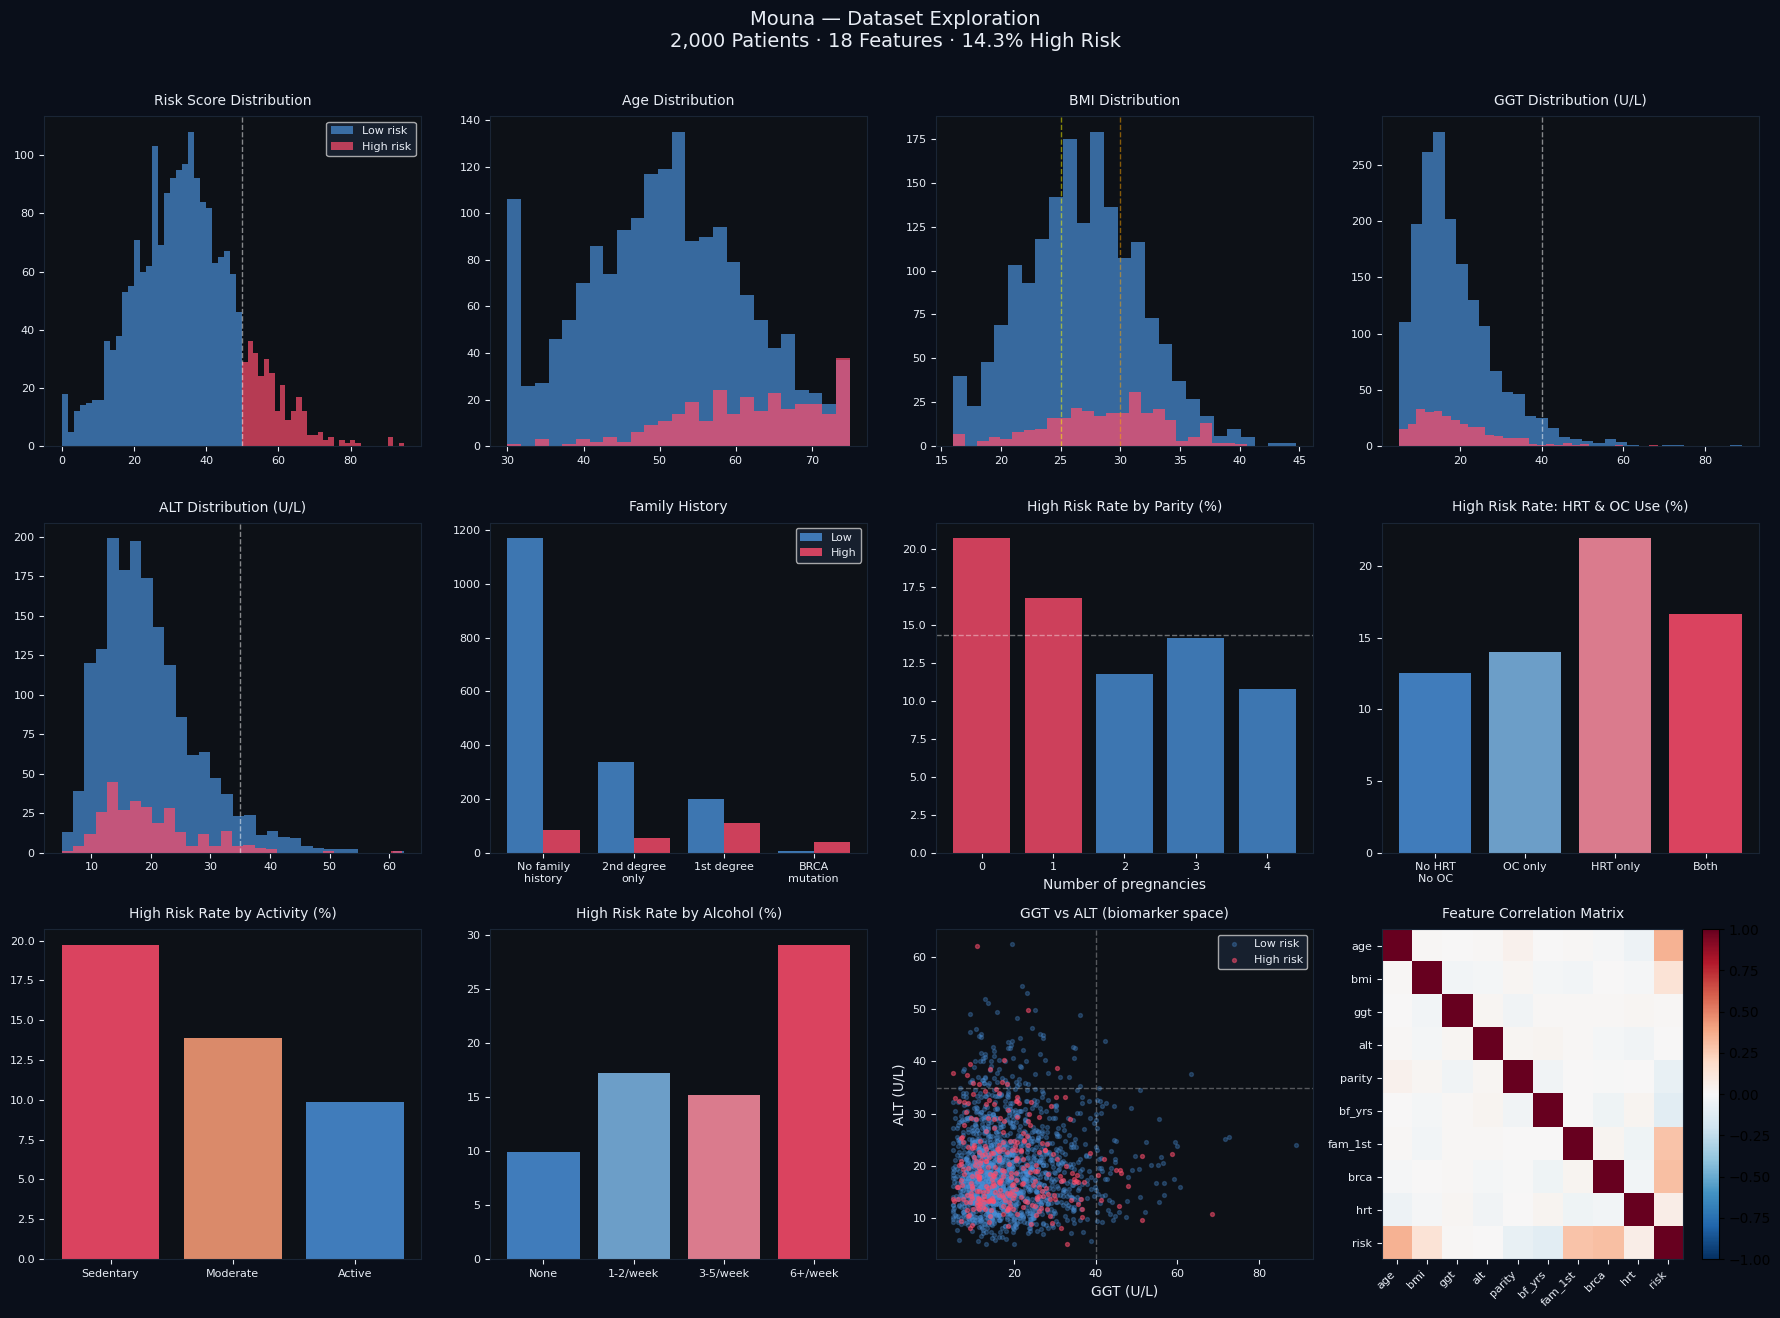

Saved to outputs/mouna_exploration.png


In [4]:
import os
os.makedirs('../outputs', exist_ok=True)

plt.savefig('../outputs/mouna_exploration.png', dpi=150,
            bbox_inches='tight', facecolor=colors['bg'])
plt.show()
print("Saved to outputs/mouna_exploration.png")
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.patch.set_facecolor('#0a0f1a')

colors = {'low': '#4A90D9', 'high': '#ff4d6d', 'bg': '#0a0f1a', 'surface': '#0d1117', 'text': '#e8edf5'}

def style_ax(ax, title):
    ax.set_facecolor(colors['surface'])
    ax.set_title(title, color=colors['text'], fontsize=10, pad=8)
    ax.tick_params(colors=colors['text'], labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2535')
    ax.xaxis.label.set_color(colors['text'])
    ax.yaxis.label.set_color(colors['text'])

low  = df[df['high_risk']==0]
high = df[df['high_risk']==1]

# 1. Risk score distribution
ax = axes[0,0]
ax.hist(low['risk_score'],  bins=30, alpha=0.7, color=colors['low'],  label='Low risk',  edgecolor='none')
ax.hist(high['risk_score'], bins=30, alpha=0.7, color=colors['high'], label='High risk', edgecolor='none')
ax.axvline(50, color='white', linestyle='--', alpha=0.5, linewidth=1)
ax.legend(fontsize=8, facecolor='#1a2535', labelcolor=colors['text'])
style_ax(ax, 'Risk Score Distribution')

# 2. Age distribution
ax = axes[0,1]
ax.hist(low['age'],  bins=25, alpha=0.7, color=colors['low'],  edgecolor='none')
ax.hist(high['age'], bins=25, alpha=0.7, color=colors['high'], edgecolor='none')
style_ax(ax, 'Age Distribution')

# 3. BMI distribution
ax = axes[0,2]
ax.hist(low['bmi'],  bins=25, alpha=0.7, color=colors['low'],  edgecolor='none')
ax.hist(high['bmi'], bins=25, alpha=0.7, color=colors['high'], edgecolor='none')
ax.axvline(25, color='yellow', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(30, color='orange', linestyle='--', alpha=0.5, linewidth=1)
style_ax(ax, 'BMI Distribution')

# 4. GGT distribution
ax = axes[0,3]
ax.hist(low['ggt'],  bins=30, alpha=0.7, color=colors['low'],  edgecolor='none')
ax.hist(high['ggt'], bins=30, alpha=0.7, color=colors['high'], edgecolor='none')
ax.axvline(40, color='white', linestyle='--', alpha=0.5, linewidth=1)
style_ax(ax, 'GGT Distribution (U/L)')

# 5. ALT distribution
ax = axes[1,0]
ax.hist(low['alt'],  bins=30, alpha=0.7, color=colors['low'],  edgecolor='none')
ax.hist(high['alt'], bins=30, alpha=0.7, color=colors['high'], edgecolor='none')
ax.axvline(35, color='white', linestyle='--', alpha=0.5, linewidth=1)
style_ax(ax, 'ALT Distribution (U/L)')

# 6. Family history
ax = axes[1,1]
cats = ['No family\nhistory', '2nd degree\nonly', '1st degree', 'BRCA\nmutation']
vals_low  = [
    ((low['family_history_1st']==0) & (low['family_history_2nd']==0) & (low['brca_mutation']==0)).sum(),
    ((low['family_history_1st']==0) & (low['family_history_2nd']==1) & (low['brca_mutation']==0)).sum(),
    ((low['family_history_1st']==1) & (low['brca_mutation']==0)).sum(),
    (low['brca_mutation']==1).sum()
]
vals_high = [
    ((high['family_history_1st']==0) & (high['family_history_2nd']==0) & (high['brca_mutation']==0)).sum(),
    ((high['family_history_1st']==0) & (high['family_history_2nd']==1) & (high['brca_mutation']==0)).sum(),
    ((high['family_history_1st']==1) & (high['brca_mutation']==0)).sum(),
    (high['brca_mutation']==1).sum()
]
x = np.arange(len(cats))
ax.bar(x-0.2, vals_low,  0.4, color=colors['low'],  alpha=0.8, label='Low')
ax.bar(x+0.2, vals_high, 0.4, color=colors['high'], alpha=0.8, label='High')
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=7)
ax.legend(fontsize=8, facecolor='#1a2535', labelcolor=colors['text'])
style_ax(ax, 'Family History')

# 7. Parity
ax = axes[1,2]
parity_rates = df.groupby('parity')['high_risk'].mean() * 100
bars = ax.bar(parity_rates.index, parity_rates.values,
              color=[colors['high'] if v > 15 else colors['low'] for v in parity_rates.values],
              alpha=0.8, edgecolor='none')
ax.axhline(14.3, color='white', linestyle='--', alpha=0.4, linewidth=1)
style_ax(ax, 'High Risk Rate by Parity (%)')
ax.set_xlabel('Number of pregnancies')

# 8. HRT and OC use
ax = axes[1,3]
groups = ['No HRT\nNo OC', 'OC only', 'HRT only', 'Both']
rates = [
    df[(df['hrt_use']==0)&(df['oral_contraceptive_use']==0)]['high_risk'].mean()*100,
    df[(df['hrt_use']==0)&(df['oral_contraceptive_use']==1)]['high_risk'].mean()*100,
    df[(df['hrt_use']==1)&(df['oral_contraceptive_use']==0)]['high_risk'].mean()*100,
    df[(df['hrt_use']==1)&(df['oral_contraceptive_use']==1)]['high_risk'].mean()*100,
]
bar_colors = ['#4A90D9','#7EB8E8','#ff8fa3','#ff4d6d']
ax.bar(groups, rates, color=bar_colors, alpha=0.85, edgecolor='none')
style_ax(ax, 'High Risk Rate: HRT & OC Use (%)')

# 9. Physical activity
ax = axes[2,0]
act_labels = ['Sedentary', 'Moderate', 'Active']
act_rates = [df[df['physical_activity']==i]['high_risk'].mean()*100 for i in range(3)]
ax.bar(act_labels, act_rates,
       color=[colors['high'], '#FFA07A', colors['low']], alpha=0.85, edgecolor='none')
style_ax(ax, 'High Risk Rate by Activity (%)')

# 10. Alcohol
ax = axes[2,1]
alc_labels = ['None', '1-2/week', '3-5/week', '6+/week']
alc_rates = [df[df['alcohol_drinks_week']==i]['high_risk'].mean()*100 for i in range(4)]
ax.bar(alc_labels, alc_rates,
       color=['#4A90D9','#7EB8E8','#ff8fa3','#ff4d6d'], alpha=0.85, edgecolor='none')
style_ax(ax, 'High Risk Rate by Alcohol (%)')

# 11. GGT vs ALT scatter
ax = axes[2,2]
ax.scatter(low['ggt'],  low['alt'],  alpha=0.3, s=8,
           color=colors['low'],  label='Low risk')
ax.scatter(high['ggt'], high['alt'], alpha=0.5, s=8,
           color=colors['high'], label='High risk')
ax.axvline(40, color='white', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(35, color='white', linestyle='--', alpha=0.3, linewidth=1)
ax.legend(fontsize=8, facecolor='#1a2535', labelcolor=colors['text'])
style_ax(ax, 'GGT vs ALT (biomarker space)')
ax.set_xlabel('GGT (U/L)')
ax.set_ylabel('ALT (U/L)')

# 12. Correlation heatmap
ax = axes[2,3]
features = ['age','bmi','ggt','alt','parity','breastfeed_years',
            'family_history_1st','brca_mutation','hrt_use','high_risk']
corr = df[features].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
labels = ['age','bmi','ggt','alt','parity','bf_yrs',
          'fam_1st','brca','hrt','risk']
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7, color=colors['text'])
ax.set_yticklabels(labels, fontsize=7, color=colors['text'])
plt.colorbar(im, ax=ax)
style_ax(ax, 'Feature Correlation Matrix')

plt.suptitle('Mouna — Dataset Exploration\n2,000 Patients · 18 Features · 14.3% High Risk',
             color=colors['text'], fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/mouna_exploration.png', dpi=150,
            bbox_inches='tight', facecolor=colors['bg'])
plt.show()
print("Saved to outputs/mouna_exploration.png")